# Analyses of model-internal activations

In [2]:
!pip install "torch==2.10.0" "transformers==5.0.0" "librosa>=0.11.0" "pandas>=2.2.2" "datasets>=4.0.0" "torchcodec==0.10.0" "seaborn>=0.13.2"
!pip install -e ".."

Defaulting to user installation because normal site-packages is not writeable
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
Using cached click-8.3.3-py3-none-any.whl (110 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///gpfs/home6/dhkloots/internal_tools
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
Using cached click-8.3.3-py3-none-any.whl (110 kB)
  Building editable for internal_tools (pyproject.toml) ... done
  Created wheel for internal_tools: filename=internal_tools-0.1.0-0.editable-py3-none-any.whl size=4212 sha256=407f84e9b0d6651043acbeda3f8b8e76142198d64920fa9d1ba0d7da6147ade2
  S

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
import gc
import torch

from tqdm import tqdm
from pathlib import Path
from collections import defaultdict

from huggingface_hub import hf_hub_download

from transformers import (
    Wav2Vec2Model,
    Wav2Vec2ForCTC,
    Wav2Vec2Config,
    HubertModel,
    HubertForCTC,
    HubertConfig,
    WavLMModel,
    WavLMForCTC,
    WavLMConfig
)
from internal_tools.models import (
    load_CPC_model,
    CPCConfig,
    load_SpidR_model,
    SpidRConfig,
    load_MelHuBERT_model,
    load_BabyHuBERT_model
)

from internal_tools.extractors import AudioModelExtractor
from internal_tools.preprocessors import AudioPreprocessor
from internal_tools.dataset_utils import get_annotated_audio_loader

from analysis_utils import create_ABX_triplets, run_phone_probe, run_ABX_tests

%matplotlib inline

In [2]:
ROOT = Path('')
DATADIR = ROOT/'data/'
MODELDIR = ROOT/'models/'
RESULTSDIR = ROOT/'results/'
FIGDIR = ROOT/'figures/'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


## Prepare analysis data

### Annotations and dataloader

In [3]:
phone_annotations = pd.read_csv(DATADIR/'libri_phone_sample/libri_phone_sample.csv')
dl = get_annotated_audio_loader(phone_annotations, DATADIR/'libri_phone_sample/audio', batch_size=50)

### Probing train-test splits

In [5]:
Nfolds = 5
test_speakers = {
    f: [
        phone_annotations[phone_annotations['speaker_sex'] == 'F']['speaker_id'].unique()[f].item(),
        phone_annotations[phone_annotations['speaker_sex'] == 'M']['speaker_id'].unique()[f].item()
    ] for f in range(Nfolds)
}

fold_splits = {
    f: {
        'train': phone_annotations[~phone_annotations['speaker_id'].isin(test_speakers[f])].index.values,
        'test': phone_annotations[phone_annotations['speaker_id'].isin(test_speakers[f])].index.values
    } for f in range(Nfolds)
}

In [6]:
fold_splits = {int(k): v for k, v in json.load(open(DATADIR/'analysis_files/phone_probe/fold_splits.json', 'r')).items()}

### ABX triplets

In [7]:
phone_contrasts = pd.read_csv(DATADIR/'analysis_files/phone_ABX/phone_contrasts.csv')
phone_contrasts

,speech_sound_category,contrast_feature,A,B
0,consonants,voicing,θ,ð
1,consonants,voicing,p,b
2,consonants,voicing,t,d
3,consonants,voicing,f,v
4,consonants,voicing,s,z
...,...,...,...,...
56,vowels,close-open,eɪ,ai
57,vowels,close-open,ɔ,u
58,vowels,close-open,oʊ,u
59,vowels,close-open,aʊ,oʊ


In [8]:
create_ABX_triplets(phone_annotations, phone_contrasts, condition='across-speaker')

,A_idx,B_idx,X_idx,A_phone,B_phone,X_phone,A_speaker_id,B_speaker_id,X_speaker_id,A_speaker_sex,B_speaker_sex,X_speaker_sex,A_file_id,B_file_id,X_file_id,speech_sound_category,contrast_feature,ABX_condition
0,340,3393,2447,θ,ð,θ,3853,6241,3752,F,M,M,3853-163249-0049,6241-66616-0019,3752-4943-0007,consonants,voicing,across-speaker
1,341,2344,1749,θ,ð,θ,3853,3752,2412,F,M,F,3853-163249-0016,3752-4943-0013,2412-153947-0008,consonants,voicing,across-speaker
2,342,1292,1748,θ,ð,θ,3853,5338,2412,F,F,F,3853-163249-0034,5338-284437-0031,2412-153947-0004,consonants,voicing,across-speaker
3,343,2346,2096,θ,ð,θ,3853,3752,422,F,M,M,3853-163249-0000,3752-4944-0021,422-122949-0014,consonants,voicing,across-speaker
4,344,597,1391,θ,ð,θ,3853,5895,5338,F,F,F,3853-163249-0003,5895-34615-0019,5338-24615-0005,consonants,voicing,across-speaker
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6095,3480,610,2080,ʌ,ɑ,ʌ,6241,5895,422,M,F,M,6241-61943-0027,5895-34629-0030,422-122949-0005,vowels,close-open,across-speaker
6096,3481,1667,2781,ʌ,ɑ,ʌ,6241,2412,6295,M,F,M,6241-61943-0017,2412-153947-0004,6295-64301-0020,vowels,close-open,across-speaker
6097,3482,1319,3139,ʌ,ɑ,ʌ,6241,5338,652,M,F,M,6241-61943-0027,5338-24615-0002,652-129742-0019,vowels,close-open,across-speaker
6098,3483,616,1389,ʌ,ɑ,ʌ,6241,5895,5338,M,F,F,6241-61946-0015,5895-34622-0013,5338-24640-0006,vowels,close-open,across-speaker


In [9]:
within_ABX_triplets = pd.read_csv(DATADIR/'analysis_files/phone_ABX/ABX_triplets_within-speaker.csv')
across_ABX_triplets = pd.read_csv(DATADIR/'analysis_files/phone_ABX/ABX_triplets_across-speaker.csv')
random_ABX_triplets = pd.read_csv(DATADIR/'analysis_files/phone_ABX/ABX_triplets_random.csv')

## Model & preprocessor loading

The `model_names` list below contains a few reference names for example models to load, for demonstration purposes. See the `load_preprocessor` and `load_model` function contents for how to load the necessary components for each of these models. 

Note: loading the `babyhubert` model requires you to sign an agreement at the HuggingFace hub (see the [BabyHuBERT model card](https://huggingface.co/MarvinLvn/BabyHuBERT)) and have your `HF_TOKEN` available as an environment variable (for example within your Colab notebook secrets). The BabyHuBERT model repository does not contain a preprocessor configuration, so loading a preprocessor for this model will default to a standard Wav2Vec2FeatureExtractor.

In [10]:
model_names = ['wav2vec2', 'wav2vec2-ctc', 'hubert', 'hubert-ctc', 'babyhubert', 'wavlm', 'wavlm-ctc', 'spidr', 'cpc', 'melhubert']

In [11]:
def load_preprocessor(model_name):
    match model_name:
        case 'wav2vec2':
            return AudioPreprocessor.for_hf_model('facebook/wav2vec2-base')
        case 'wav2vec2-ctc': 
            return AudioPreprocessor.for_hf_model('facebook/wav2vec2-base-960h')
        case 'hubert': 
            return AudioPreprocessor.for_hf_model('facebook/hubert-base-ls960')
        case 'hubert-ctc': 
            return AudioPreprocessor.for_hf_model('facebook/hubert-large-ls960-ft')
        case 'babyhubert':
            return AudioPreprocessor.for_hf_model('MarvinLvn/BabyHuBERT')
        case 'wavlm': 
            return AudioPreprocessor.for_hf_model('microsoft/wavlm-base')
        case 'wavlm-ctc':
            return AudioPreprocessor.for_hf_model('patrickvonplaten/wavlm-libri-clean-100h-base')
        case 'spidr':
            return AudioPreprocessor.for_spidr_model()
        case 'cpc': 
            return AudioPreprocessor.for_cpc_model()
        case 'melhubert':
            return AudioPreprocessor.for_melhubert_model()

def load_model(model_name, trained=True):
    match model_name:
        case 'wav2vec2': 
            if trained:
                return Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(device)
            else:
                return Wav2Vec2Model(Wav2Vec2Config()).to(device)
        case 'wav2vec2-ctc': 
            if trained:
                return Wav2Vec2ForCTC.from_pretrained('facebook/wav2vec2-base-960h').to(device)
            else:
                return Wav2Vec2ForCTC(Wav2Vec2Config()).to(device)
        case 'hubert': 
            if trained:
                return HubertModel.from_pretrained('facebook/hubert-base-ls960').to(device)
            else:
                return HubertModel(HubertConfig()).to(device)
        case 'hubert-ctc': 
            if trained:
                return HubertForCTC.from_pretrained('facebook/hubert-large-ls960-ft').to(device)
            else:
                return HubertForCTC(HubertConfig()).to(device)
        case 'babyhubert':
            if trained:
                return load_BabyHuBERT_model(hf_hub_download(repo_id="MarvinLvn/BabyHuBERT", filename="BabyHuBERT.ckpt")).to(device)
            else:
                return load_BabyHuBERT_model().to(device)
        case 'wavlm': 
            if trained:
                return WavLMModel.from_pretrained('microsoft/wavlm-base').to(device)
            else:
                return WavLMModel(WavLMConfig()).to(device)
        case 'wavlm-ctc':
            if trained:
                return WavLMForCTC.from_pretrained('patrickvonplaten/wavlm-libri-clean-100h-base').to(device)
            else:
                return WavLMForCTC(WavLMConfig()).to(device)
        case 'spidr':
            if trained:
                return torch.hub.load("facebookresearch/spidr", "spidr_base").to(device)
            else:
                return load_SpidR_model(SpidRConfig()).to(device)
        case 'cpc': 
            if trained:
                return load_CPC_model("cpc_checkpoint_106.pt").to(device)
            else:
                return load_CPC_model(CPCConfig()).to(device)
        case 'melhubert':
            if trained:
                return load_MelHuBERT_model('melhubert_960_stage2_20ms.ckpt').to(device)
            else:
                return load_MelHuBERT_model(config='default_20ms').to(device)

## Embedding extraction & analyses

In [14]:
model_name = 'babyhubert'
trained = True
save_result_files = False

model = load_model(model_name, trained=trained)
model.eval()
model.to(device)

preprocessor = load_preprocessor(model_name)

# initialize the extractor (with default configurations)
extr = AudioModelExtractor(model)

# we will store batchwise activations & indices here
actv_indices = []
activations = defaultdict(list)

print('Extracting activations...')
for b, batch_data in tqdm(enumerate(dl), desc=f'For {len(dl)} batches', total=len(dl)):

    # prepare audio inputs (create padded & preprocessed waveforms or mel spectrograms)
    inputs = preprocessor(
        batch_data['audio_signal'],
        sampling_rate=batch_data['audio_sampling_rate'],
        padding=True,
        return_tensors="pt",
        padding_side="right"
    ).to(device)
    
    # max length of all the waveforms in this batch
    # for waveform preprocessors with padding, this will be equal to inputs.input_values.shape[-1]
    # for mel preprocessors, the preprocessed input shape will depend on the frame period; 
    #    e.g. for a mel preprocessor with a frame period of 20 ms
    #    inputs.input_values.shape[1] will be int(max_audio_size/(0.02*sampling_rate))
    max_audio_size = max([len(s) for s in batch_data['audio_signal']])

    # run forward pass
    with torch.no_grad():
        if model_name == 'melhubert':
            outputs = model(inputs.input_values, inputs.attention_mask)
        else:
            outputs = model(inputs.input_values)

    # extract and mean-pool segment activations
    extracted_actv_indices, extracted_acts = extr.get_indexed_segment_activations(
        segment_index=batch_data['annotation_indices'], 
        segment_start_times=batch_data['annotation_start_times'],
        segment_end_times=batch_data['annotation_end_times'],
        input_size=max_audio_size, 
        pooling='mean'
    )

    # clear memory
    extr.clear()
    del inputs, outputs
    gc.collect()
    torch.cuda.empty_cache()

    # store extracted activations & their indices
    actv_indices.extend(extracted_actv_indices)
    for layer in extracted_acts:
        activations[layer].extend(extracted_acts[layer])

# reorder extracted activations by indices & stack
for layer in activations.keys():
    activations[layer] = np.stack([activations[layer][i] for i in np.argsort(actv_indices)])
print('Done!')
print(f'Extracted activations for {model_name} layers:', list(activations.keys()))

first_model_layer = 'embeds' if not model_name == 'cpc' else 'LSTM'

# here we run analyses on the extracted activations
print('Running probing classifiers...')
print('True labels')
probe_true_results = run_phone_probe(
    activations, phone_annotations, fold_splits, 
    first_model_layer=first_model_layer
)
print('Randomized labels')
probe_control_results = run_phone_probe(
    activations, phone_annotations, fold_splits, 
    first_model_layer=first_model_layer, 
    randomize_labels=True
)

print('Running ABX tests...')
print('within-speaker')
ABX_within_results = run_ABX_tests(
    activations, 
    within_ABX_triplets, 
    device=device, 
    first_model_layer=first_model_layer
)
print('across-speaker')
ABX_across_results = run_ABX_tests(
    activations, 
    across_ABX_triplets, 
    device=device, 
    first_model_layer=first_model_layer
)
print('random')
ABX_random_results = run_ABX_tests(
    activations, 
    random_ABX_triplets, 
    device=device, 
    first_model_layer=first_model_layer
)
print('Done!')

if save_result_files:
    model_init = 'trained' if trained else 'untrained'
    ABX_within_results.to_csv(RESULTSDIR / f"ABX-results_within-speaker_{model_name}-{model_init}.csv", index=False)
    ABX_across_results.to_csv(RESULTSDIR / f"ABX-results_across-speaker_{model_name}-{model_init}.csv", index=False)
    ABX_random_results.to_csv(RESULTSDIR / f"ABX-results_random_{model_name}-{model_init}.csv", index=False)

# clear memory
del model, extr, activations
gc.collect()
torch.cuda.empty_cache()

Extracting activations...


for 13 batches: 100%|██████████| 13/13 [00:12<00:00,  1.05it/s]


Done!
Extracted activations for babyhubert layers: ['CNN', 'embeds', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12']
Running probing classifiers...
True labels


fold 4: 100%|██████████| 14/14 [00:08<00:00,  1.69it/s]


Randomized labels


...

across-speaker


100%|██████████| 14/14 [01:04<00:00,  4.59s/it]


random


100%|██████████| 14/14 [01:04<00:00,  4.60s/it]


Done!


## Plot results

### Probe results

In [5]:
model_names = ['wav2vec2', 'wavlm', 'spidr', 'hubert', 'babyhubert', 'melhubert', 'cpc']
trained_model_probe_results = {
    model_name: {
        label_setting: pd.read_csv(RESULTSDIR/f'probe-results_{label_setting}-labels_{model_name}-trained.csv')
        for label_setting in ['true', 'randomized']
    }
    for model_name in model_names
}
untrained_model_probe_results = {
    model_name: {
        label_setting: pd.read_csv(RESULTSDIR/f'probe-results_{label_setting}-labels_{model_name}-untrained.csv')
        for label_setting in ['true', 'randomized']
    }
    for model_name in model_names
}

In [25]:
def plot_probe_results(probe_results, title='', filepath=None, model_names=model_names):
    sns.set_style('whitegrid')
    mpl.rcParams['axes.linewidth'] = 2
    mpl.rcParams['axes.edgecolor'] = '0.9'
    width_frac = 1
    if 'cpc' in model_names:
        cpc_idx = model_names.index('cpc')
        cpc_frac = width_frac/4
    width_ratios = [width_frac if not mn == 'cpc' else cpc_frac for mn in model_names]
    
    fig, axs = plt.subplots(1, len(model_names), figsize=(2.25*len(model_names),3), width_ratios=width_ratios, sharey=True)
    
    for mn, model_name in enumerate(model_names):
        ax = axs[mn]
        results = probe_results[model_name]
        foldavg_true = results['true'].groupby(['fold', 'layer', 'depth'], as_index=False).agg({'score': 'mean'})
        foldavg_control = results['randomized'].groupby(['fold', 'layer', 'depth'], as_index=False).agg({'score': 'mean'})
        sns.lineplot(foldavg_true, x='depth', y='score', ax=ax, label='true phone labels')
        sns.lineplot(foldavg_control, x='depth', y='score', dashes=(1,2), color='grey', ax=ax, label='randomized labels')
        layer_depths = dict(zip(results['true']['layer'].unique(), results['true']['depth'].unique()))
        ax.set_xticks(list(layer_depths.values()), list(layer_depths.keys()), rotation=90)
        ax.set_xlim(list(layer_depths.values())[0], list(layer_depths.values())[-1])
        ax.set_xlabel('')
        ax.set_ylabel('accuracy')
        ax.set_ylim(0,1)
        if mn == 0:
            ax.legend(frameon=False, ncol=2, bbox_to_anchor=(7.4,1.33,0,0))
        else:
            ax.legend().remove()
        ax.set_title(model_name, ha='left', x=0)
    if title:
        plt.suptitle(title.upper(), ha='left', x=0.095, y=1.1, fontweight='bold')
    if filepath:
        if not filepath.parent.exists():
            Path(filepath).mkdir(exist_ok=True, parents=True)
        plt.savefig(filepath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

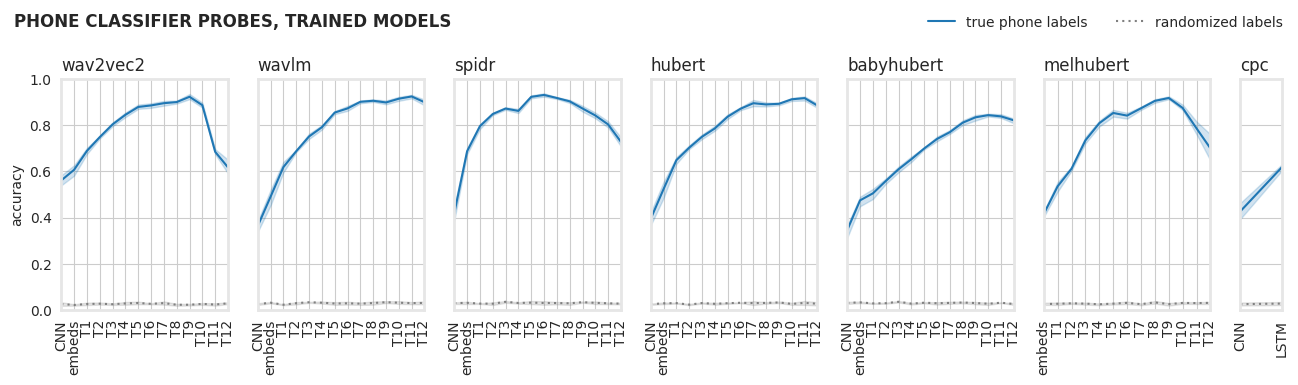

In [26]:
plot_probe_results(
    trained_model_results, 
    title='phone classifier probes, trained models', 
    filepath='trained_probe_results.png'
)

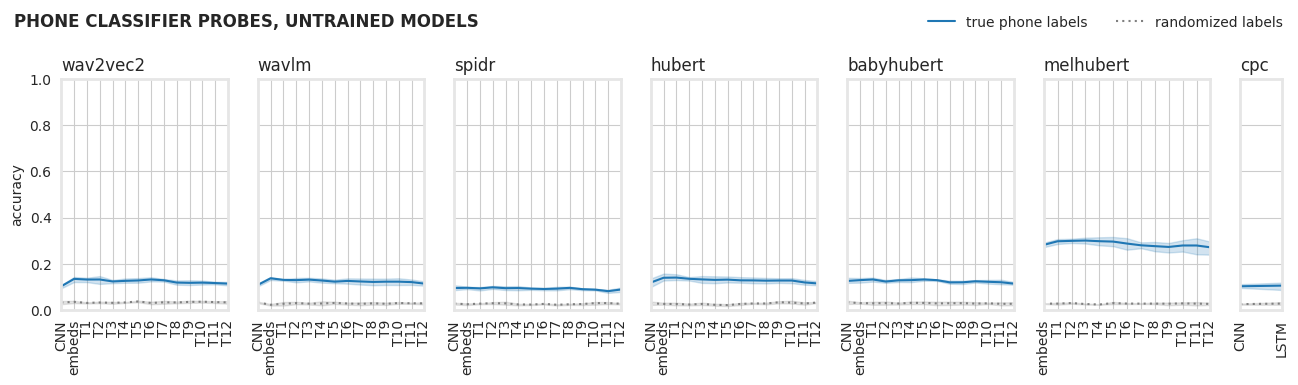

In [27]:
plot_probe_results(
    untrained_model_results, 
    title='phone classifier probes, untrained models', 
    filepath='untrained_probe_results.png'
)

## Plot ABX results

In [10]:
model_names = ['wav2vec2', 'wavlm', 'spidr', 'hubert', 'babyhubert', 'melhubert', 'cpc']
trained_model_ABX_results = {
    model_name: {
        condition: pd.read_csv(RESULTSDIR/f'ABX-results_{condition}_{model_name}-trained.csv')
        for condition in ['within-speaker', 'across-speaker', 'random']
    }
    for model_name in model_names
}
untrained_model_ABX_results = {
    model_name: {
        condition: pd.read_csv(RESULTSDIR/f'ABX-results_{condition}_{model_name}-untrained.csv')
        for condition in ['within-speaker', 'across-speaker', 'random']
    }
    for model_name in model_names
}

In [22]:
def plot_ABX_results(ABX_results, title='', filepath=None, model_names=model_names, conditions=['within-speaker', 'across-speaker', 'random']):
    sns.set_style('whitegrid')
    mpl.rcParams['axes.linewidth'] = 2
    mpl.rcParams['axes.edgecolor'] = '0.9'
    width_frac = 1
    if 'cpc' in model_names:
        cpc_idx = model_names.index('cpc')
        cpc_frac = width_frac/4
    width_ratios = [width_frac if not mn == 'cpc' else cpc_frac for mn in model_names]
    
    fig, axs = plt.subplots(1, len(model_names), figsize=(2.25*len(model_names),3), width_ratios=width_ratios, sharey=True)
    
    for mn, model_name in enumerate(model_names):
        ax = axs[mn]
        results = ABX_results[model_name]
        for condition in conditions:
            condition_results = results[condition]
            if condition == 'within-speaker':
                sns.lineplot(condition_results, x='depth', y='accuracy', ax=ax, label='within-speaker', color=sns.color_palette("Paired")[3])
            elif condition == 'across-speaker':
                sns.lineplot(condition_results, x='depth', y='accuracy', ax=ax, label='across-speaker', color=sns.color_palette("Paired")[2])
            elif condition == 'random':
                sns.lineplot(condition_results, x='depth', y='accuracy', ax=ax, label='random', color='grey', dashes=(1,2))
        layer_depths = dict(zip(results[conditions[0]]['layer'].unique(), results[conditions[0]]['depth'].unique()))
        ax.set_xticks(list(layer_depths.values()), list(layer_depths.keys()), rotation=90)
        ax.set_xlim(list(layer_depths.values())[0], list(layer_depths.values())[-1])
        ax.set_xlabel('')
        ax.set_ylabel('accuracy')
        ax.set_ylim(0.45,1)
        if mn == 0:
            ax.legend(frameon=False, ncol=3, bbox_to_anchor=(7.4,1.33,0,0))
        else:
            ax.legend().remove()
        ax.set_title(model_name, ha='left', x=0)
    if title:
        plt.suptitle(title.upper(), ha='left', x=0.095, y=1.1, fontweight='bold')
    if filepath:
        if not filepath.parent.exists():
            Path(filepath).mkdir(exist_ok=True, parents=True)
        plt.savefig(filepath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

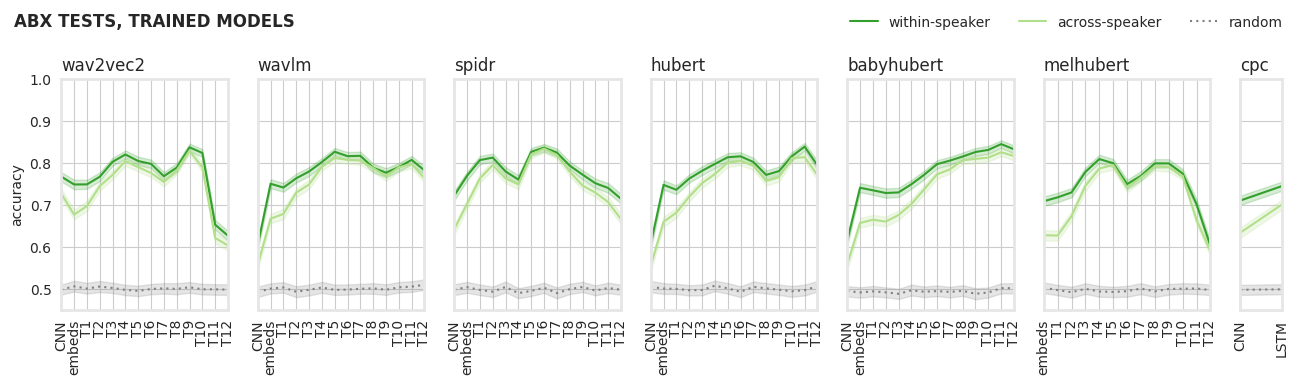

In [23]:
plot_ABX_results(trained_model_ABX_results, 'ABX tests, trained models')

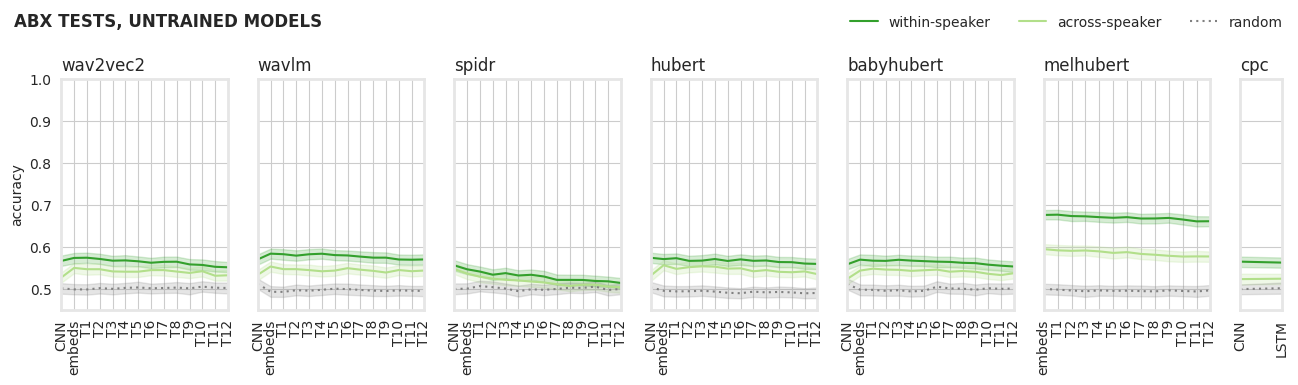

In [24]:
plot_ABX_results(untrained_model_ABX_results, 'ABX tests, untrained models')